In [1]:
# load the computed controller and certificate from the generated python file
import sympy as sp

from sop_bounded_control_ex1_debug_20260314_191715 import (
    u_opt,
    certificate_opt,
)

# reshape u_opt as a (2, 1) sympy matrix  [F; M]
u_opt = sp.Matrix(u_opt)

print("Symbols in u_opt[0] (F):", u_opt[0].free_symbols)
print("Symbols in u_opt[1] (M):", u_opt[1].free_symbols)
print("Symbols in certificate_opt:", certificate_opt.free_symbols)

Symbols in u_opt[0] (F): {px, vx, vz, pz, om, th}
Symbols in u_opt[1] (M): {px, vx, vz, pz, om, th}
Symbols in certificate_opt: {vz, om, th, px, vx, pz}


In [2]:
import numpy as np

# State and output variables
px, pz, th, vx, vz, om = sp.symbols("px pz th vx vz om")
y1, y2 = sp.symbols("y1 y2")
state_vars = [px, pz, th, vx, vz, om]

# Physical parameters
g_grav = 9.81
m_mass = 1.0
I_inertia = 0.1
L = 1.0  # nozzle arm length [m]

# System dynamics  x_dot = f(x) + g(x) u
f_sym = sp.Matrix([vx, vz, om, 0, -g_grav, 0])
g_sym = sp.Matrix(
    [
        [0, 0],
        [0, 0],
        [0, 0],
        [sp.sin(th) / m_mass, 0],
        [sp.cos(th) / m_mass, 0],
        [0, -1 / I_inertia],
    ]
)

# Output mapping: tip position  y = h(x)
hx = sp.Matrix([px - L * sp.sin(th), pz - L * sp.cos(th)])  # y1, y2

# ── Target set: flat ellipse — tight in y2, relaxed in y1 ────────────────────
x_target, z_target = 0.0, 1.0  # target centre in y-space
r_y1 = 0.3  # semi-axis in y1 [m]  (larger  -> more relaxed horizontally)
r_y2 = 0.05  # semi-axis in y2 [m]  (smaller -> tighter  vertically, flat shape)
target_set_y = (y1 - x_target) ** 2 / r_y1**2 + (y2 - z_target) ** 2 / r_y2**2 - 1

# ── Safe set: tilted squircle — same boundary, peak placed at z_peak ──────────
# psi = squircle(y) * (1 + beta*(y2 - z_c))
#   boundary : zero-level set identical to the plain squircle (shape/position unchanged)
#   peak     : analytically placed at (x_c, z_peak) by computing beta from z_peak
#   formula  : beta = 4*C*u^3 / (W_x^4 - 5*C*u^4),  u = z_peak-z_c, C = (W_x/W_z)^4
#   validity : |z_peak - z_c| < W_z * (1/5)**0.25  ~  0.669 * W_z
W_x = 2.0  # half-width in y1 direction [m]
W_z = 2.0  # half-width in y2 direction [m]
x_c = 0.0  # squircle centre in y1 [m]
z_c = 1  # squircle centre in y2 [m]

C_coeff = (W_x / W_z) ** 4
safe_set_y = W_x**4 - (y1 - x_c) ** 4 - C_coeff * (y2 - z_c) ** 4


# Substitute y = h(x) to get expressions in state space
safe_set_x = safe_set_y.subs({y1: hx[0], y2: hx[1]})
target_set_x = target_set_y.subs({y1: hx[0], y2: hx[1]})

print("h(x):", hx.T)
print("safe_set   (y):", safe_set_y)
print("target_set (y):", target_set_y)

h(x): Matrix([[px - 1.0*sin(th), pz - 1.0*cos(th)]])
safe_set   (y): -y1**4 - 1.0*(y2 - 1)**4 + 16.0
target_set (y): 11.1111111111111*y1**2 + 400.0*(y2 - 1.0)**2 - 1


In [3]:
# Sample 6-D state space
N_samples = 10000
np.random.seed(42)

# bounds: [px, pz, th, vx, vz, om]
lower_bound = np.array([-2.0, 0, -np.pi / 6, -0.1, -0.1, -0.1])
upper_bound = np.array([2.0, 4, np.pi / 6, 0.1, 0.1, 0.1])

x_samples = np.random.rand(6, N_samples) * (upper_bound - lower_bound).reshape(
    -1, 1
) + lower_bound.reshape(-1, 1)

print("x_samples shape:", x_samples.shape)
names = ["px", "pz", "th", "vx", "vz", "om"]
for i, n in enumerate(names):
    print(f"  {n}: [{x_samples[i].min():.3f}, {x_samples[i].max():.3f}]")

x_samples shape: (6, 10000)
  px: [-2.000, 1.999]
  pz: [0.001, 4.000]
  th: [-0.524, 0.523]
  vx: [-0.100, 0.100]
  vz: [-0.100, 0.100]
  om: [-0.100, 0.100]


In [4]:
# Evaluate certificate and filter valid initial states
certificate_func = sp.lambdify(state_vars, certificate_opt, "numpy")
safe_set_x_func = sp.lambdify(state_vars, safe_set_x, "numpy")
target_set_x_func = sp.lambdify(state_vars, target_set_x, "numpy")
safe_set_y_func = sp.lambdify([y1, y2], safe_set_y, "numpy")
target_set_y_func = sp.lambdify([y1, y2], target_set_y, "numpy")

cert_vals = np.atleast_1d(np.squeeze(certificate_func(*x_samples)))
safe_vals = np.atleast_1d(np.squeeze(safe_set_x_func(*x_samples)))
target_vals = np.atleast_1d(np.squeeze(target_set_x_func(*x_samples)))

if cert_vals.shape == ():
    cert_vals = np.full(N_samples, float(cert_vals))
if safe_vals.shape == ():
    safe_vals = np.full(N_samples, float(safe_vals))
if target_vals.shape == ():
    target_vals = np.full(N_samples, float(target_vals))

valid_idx = np.where((cert_vals >= 0) & (target_vals > 0) & (safe_vals >= 0))[0]

x_valid = x_samples[:, valid_idx]
print(f"Valid: {len(valid_idx)} / {N_samples}")
print(f"Using {x_valid.shape[1]} initial conditions for simulation")

Valid: 5151 / 10000
Using 5151 initial conditions for simulation


y_valid shape: (5151,)


/var/folders/98/l4vl60j93tg9_xs4dt8kbvy40000gn/T/ipykernel_26144/1284008903.py:25: UserWarning: The following kwargs were not used by contour: 'label'
  cs_safe = ax.contour(
/var/folders/98/l4vl60j93tg9_xs4dt8kbvy40000gn/T/ipykernel_26144/1284008903.py:29: UserWarning: The following kwargs were not used by contour: 'label'
  cs_target = ax.contour(


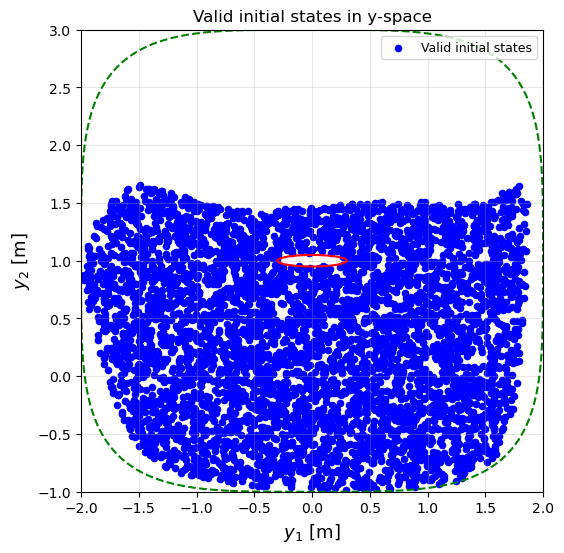

In [5]:
# visualuze the valid initial states in y-space
y_valid = np.array(
    [
        safe_set_y_func(
            hx[0].subs(dict(zip(state_vars, x_valid[:, i]))),
            hx[1].subs(dict(zip(state_vars, x_valid[:, i]))),
        )
        for i in range(x_valid.shape[1])
    ]
)
print("y_valid shape:", y_valid.shape)

# visualize the safe set and target set boundaries in y-space, along with the valid initial states
n_grid = 500
y1_g = np.linspace(-2.0, 2.0, n_grid)
y2_g = np.linspace(-1, 3, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe = safe_set_y_func(Y1, Y2)
Z_target = target_set_y_func(Y1, Y2)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# safe set boundary
cs_safe = ax.contour(
    Y1, Y2, Z_safe, levels=[0], colors="g", linestyles="--", label="Safe set"
)
# target set boundary
cs_target = ax.contour(
    Y1, Y2, Z_target, levels=[0], colors="r", linestyles="-", label="Target set"
)
# valid initial states
ax.scatter(
    [hx[0].subs(dict(zip(state_vars, x_valid[:, i]))) for i in range(x_valid.shape[1])],
    [hx[1].subs(dict(zip(state_vars, x_valid[:, i]))) for i in range(x_valid.shape[1])],
    color="b",
    s=20,
    label="Valid initial states",
)
ax.set_xlabel("$y_1$ [m]", fontsize=13)
ax.set_ylabel("$y_2$ [m]", fontsize=13)
ax.set_title("Valid initial states in y-space", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.show()

In [6]:
# Build closed-loop dynamics
cl_dyn = f_sym + g_sym @ u_opt
print("Closed-loop state dimension:", cl_dyn.shape)

dyn_cl_f = sp.lambdify(state_vars, cl_dyn, "numpy")
hx_func = sp.lambdify(state_vars, hx, "numpy")
target_x_func = sp.lambdify(state_vars, target_set_x, "numpy")

Closed-loop state dimension: (6, 1)


In [7]:
from joblib import Parallel, delayed
import numpy as np

dt = 0.01
max_steps = 2000

# suppress numpy overflow/invalid warnings from the polynomial controller
# (diverged states are detected via isfinite and skipped, not propagated)
np.seterr(over="ignore", invalid="ignore")


# ── Fixed-step RK4 ───────────────────────────────────────────────────────────
def rk4_step(dyn, x, dt):
    k1 = np.array(dyn(*x)).flatten()
    k2 = np.array(dyn(*(x + 0.5 * dt * k1))).flatten()
    k3 = np.array(dyn(*(x + 0.5 * dt * k2))).flatten()
    k4 = np.array(dyn(*(x + dt * k3))).flatten()
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# ── Single-trajectory simulation — returns None if the state diverges ─────────
def simulate_one(x0):
    x_cur = x0.copy()
    xs = [x_cur.copy()]
    ys = [np.array(hx_func(*x_cur)).flatten()]

    phi = float(np.squeeze(target_x_func(*x_cur)))
    steps = 0
    while phi > 0 and steps < max_steps:
        x_next = rk4_step(dyn_cl_f, x_cur, dt)
        if not np.all(np.isfinite(x_next)):  # state diverged — discard
            return None
        x_cur = x_next
        phi = float(np.squeeze(target_x_func(*x_cur)))
        xs.append(x_cur.copy())
        ys.append(np.array(hx_func(*x_cur)).flatten())
        steps += 1

    return np.stack(xs), np.stack(ys)


# ── Parallel execution ────────────────────────────────────────────────────────
# select the from the valid initial states for simulation (e.g., all, or a random subset if too many)
# sort the valid initial states by their target set value (phi) to prioritize those far away from the target for simulation
x_valid = x_valid[:, :20]
# x_valid = x_valid[
#     :,
#     np.argsort(
#         [
#             float(np.squeeze(target_x_func(*x_valid[:, i])))
#             for i in range(x_valid.shape[1])
#         ]
#     ),
# ]
# pick the last 20 for simulation if there are too many valid states (adjust as needed)
# x_valid = x_valid[:, -20:]  # --- IGNORE ---
results = Parallel(n_jobs=-1, prefer="threads")(
    delayed(simulate_one)(x_valid[:, i]) for i in range(x_valid.shape[1])
)


# filter out diverged (None) trajectories
n_total = len(results)
results = [r for r in results if r is not None]
n_ok = len(results)
print(
    f"Valid trajectories: {n_ok} / {n_total}  ({n_total - n_ok} diverged and skipped)"
)

if n_ok == 0:
    raise RuntimeError(
        "All trajectories diverged — check controller validity or reduce dt."
    )

traj_x, traj_y = zip(*results)
traj_x = list(traj_x)
traj_y = list(traj_y)

for i, (tx, _) in enumerate(zip(traj_x, traj_y)):
    if (i + 1) % max(1, n_ok // 10) == 0:
        phi_f = float(np.squeeze(target_x_func(*tx[-1])))
        print(f"  traj {i+1:3d}: {len(tx)-1} steps, phi_final={phi_f:.4f}")

print(f"Done. {len(traj_x)} trajectories available for plotting.")

Valid trajectories: 20 / 20  (0 diverged and skipped)
  traj   2: 2000 steps, phi_final=4.7901
  traj   4: 2000 steps, phi_final=4.6425
  traj   6: 2000 steps, phi_final=3.9284
  traj   8: 2000 steps, phi_final=2.6693
  traj  10: 2000 steps, phi_final=5.0571
  traj  12: 13 steps, phi_final=-0.9080
  traj  14: 2000 steps, phi_final=4.8152
  traj  16: 2000 steps, phi_final=3.9020
  traj  18: 2000 steps, phi_final=1.7253
  traj  20: 13 steps, phi_final=-0.9323
Done. 20 trajectories available for plotting.


/var/folders/98/l4vl60j93tg9_xs4dt8kbvy40000gn/T/ipykernel_26144/3199269181.py:30: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(
/var/folders/98/l4vl60j93tg9_xs4dt8kbvy40000gn/T/ipykernel_26144/3199269181.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


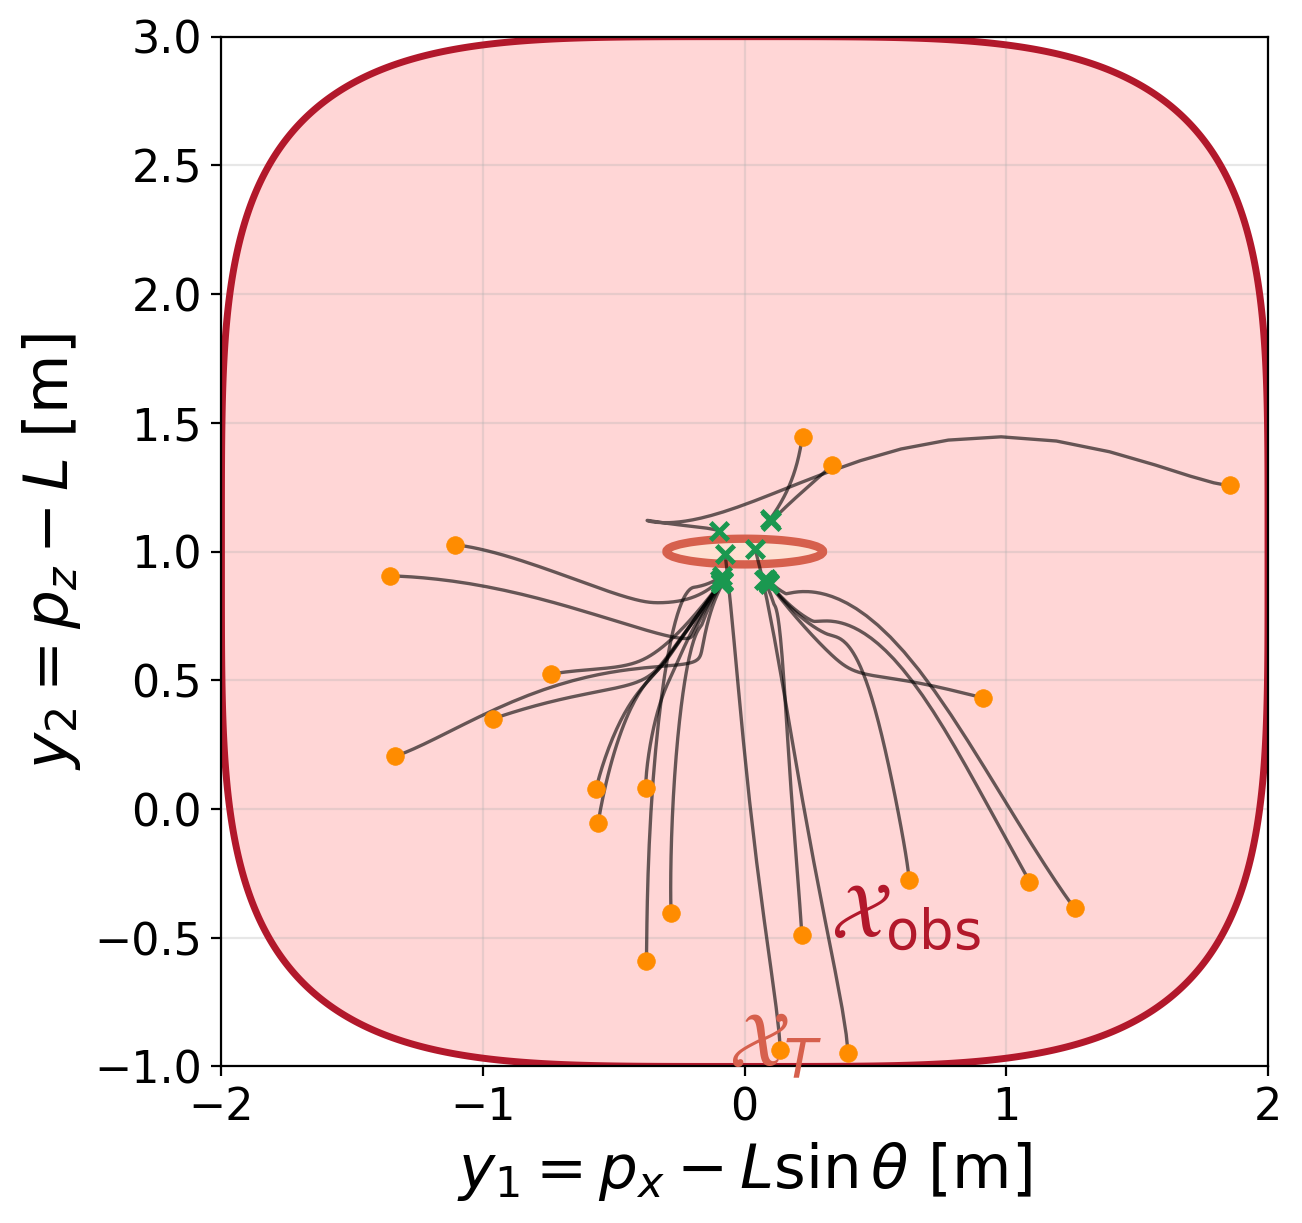

In [8]:
# Visualise closed-loop tip trajectories in y-space
from functional import BetterColor

y1_g = np.linspace(-2.0, 2.0, 500)
y2_g = np.linspace(-1, 3, 500)
Y1, Y2 = np.meshgrid(y1_g, y2_g)

safe_f_y = sp.lambdify([y1, y2], safe_set_y, "numpy")
target_f_y = sp.lambdify([y1, y2], target_set_y, "numpy")
Z_safe_y = safe_f_y(Y1, Y2)
Z_tgt_y = target_f_y(Y1, Y2)

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

# Obstacle region
ax.contourf(
    Y1, Y2, Z_safe_y, levels=[0, np.inf], colors=["#ffcccc"], alpha=0.8, zorder=1
)
ax.contour(Y1, Y2, Z_safe_y, levels=[0], colors=["#b2182b"], linewidths=2.5, zorder=2)
# Target region
ax.contourf(
    Y1, Y2, Z_tgt_y, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1, Y2, Z_tgt_y, levels=[0], colors=["#d6604d"], linewidths=3, zorder=4)
# Trajectories
for ty in traj_y:
    ax.plot(ty[:, 0], ty[:, 1], color="black", lw=1.2, alpha=0.6, zorder=10)
    ax.scatter(
        ty[0, 0],
        ty[0, 1],
        s=40,
        c=BetterColor.orange3(),
        marker="o",
        linewidths=0.3,
        zorder=20,
    )
    ax.scatter(
        ty[-1, 0],
        ty[-1, 1],
        s=40,
        c=BetterColor.green0(),
        marker="x",
        linewidths=1.8,
        zorder=20,
    )

fs = 28
ax.text(
    0.33,
    -0.5,
    "$\\mathcal{X}_{\\mathrm{obs}}$",
    fontsize=fs,
    color="#b2182b",
    zorder=30,
)
ax.text(-0.06, -1.0, "$\\mathcal{X}_T$", fontsize=fs, color="#d6604d", zorder=30)
ax.set_xlabel("$y_1 = p_x - L\\sin\\theta$ [m]", fontsize=fs - 6)
ax.set_ylabel("$y_2 = p_z - L$ [m]", fontsize=fs - 6)
ax.xaxis.set_tick_params(labelsize=16)
ax.yaxis.set_tick_params(labelsize=16)
ax.grid(True, alpha=0.3)
plt.show()

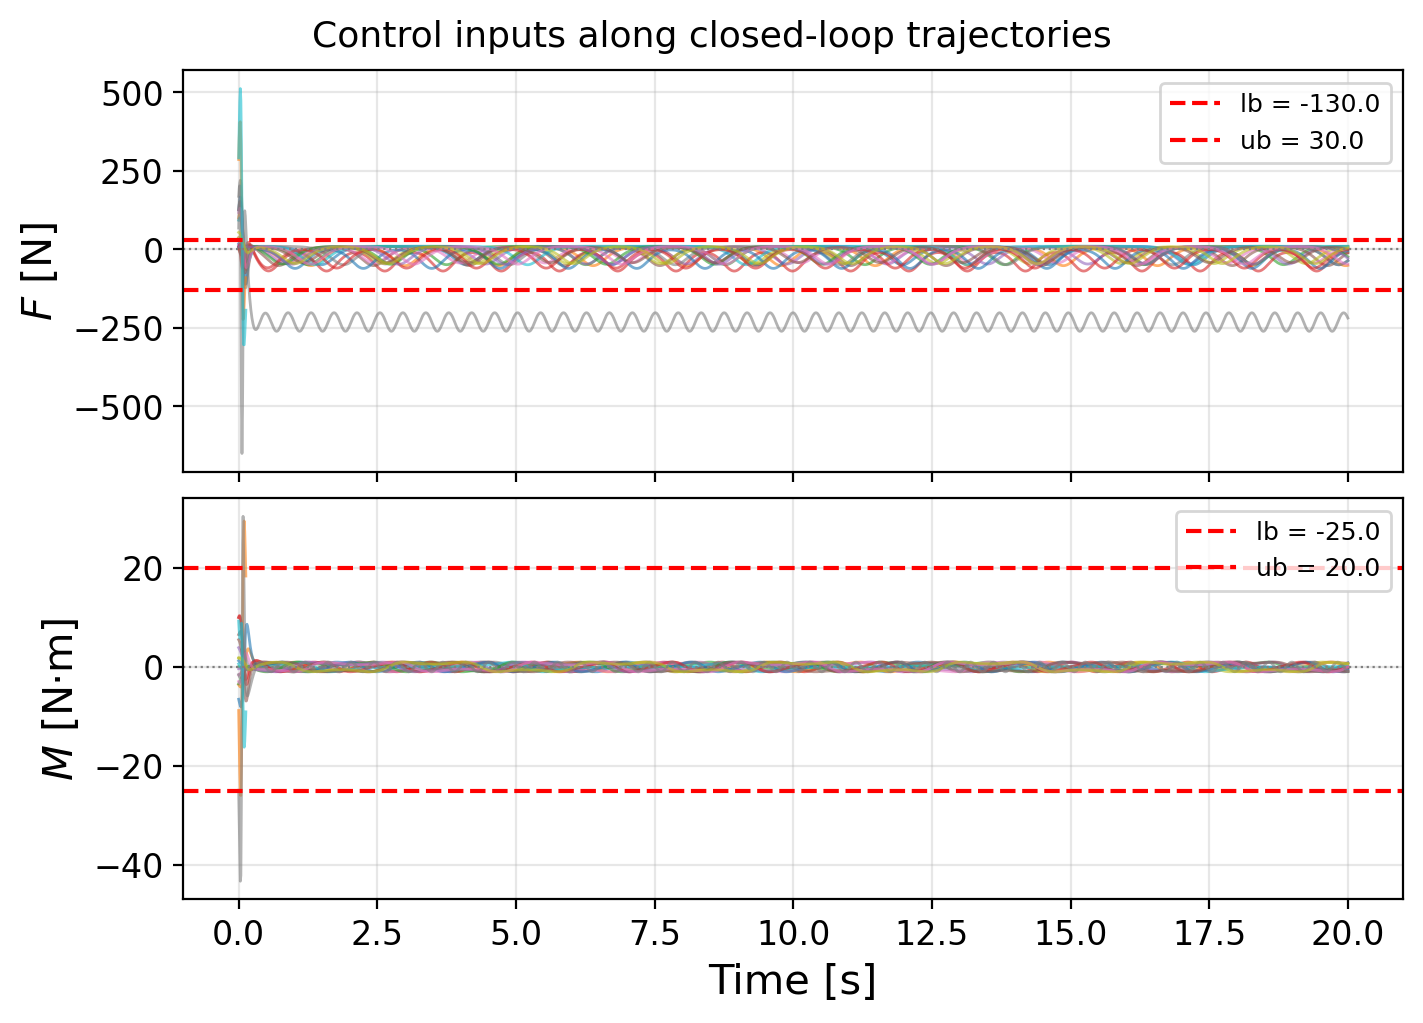

In [9]:
# Control inputs F (thrust) and M (moment) along trajectories
F_func = sp.lambdify(state_vars, u_opt[0], "numpy")
M_func = sp.lambdify(state_vars, u_opt[1], "numpy")

lb = np.array([-130.0, -25.0])
ub = np.array([30.0, 20.0])

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    2, 1, figsize=(700 * px_fig, 500 * px_fig), layout="constrained", sharex=True
)
fig.set_dpi(200)

for tx in traj_x:
    t = np.arange(tx.shape[0]) * dt
    axes[0].plot(t, np.array(F_func(*tx.T)).flatten(), lw=1.0, alpha=0.6)
    axes[1].plot(t, np.array(M_func(*tx.T)).flatten(), lw=1.0, alpha=0.6)

for ax, (lo, hi), lbl in zip(
    axes, [(lb[0], ub[0]), (lb[1], ub[1])], ["$F$ [N]", "$M$ [N\u00b7m]"]
):
    ax.axhline(lo, color="red", lw=1.5, ls="--", label=f"lb = {lo}")
    ax.axhline(hi, color="red", lw=1.5, ls="--", label=f"ub = {hi}")
    ax.axhline(0, color="gray", lw=0.8, ls=":")
    ax.set_ylabel(lbl, fontsize=15)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)


axes[1].set_xlabel("Time [s]", fontsize=15)
fig.suptitle("Control inputs along closed-loop trajectories", fontsize=13)
plt.show()

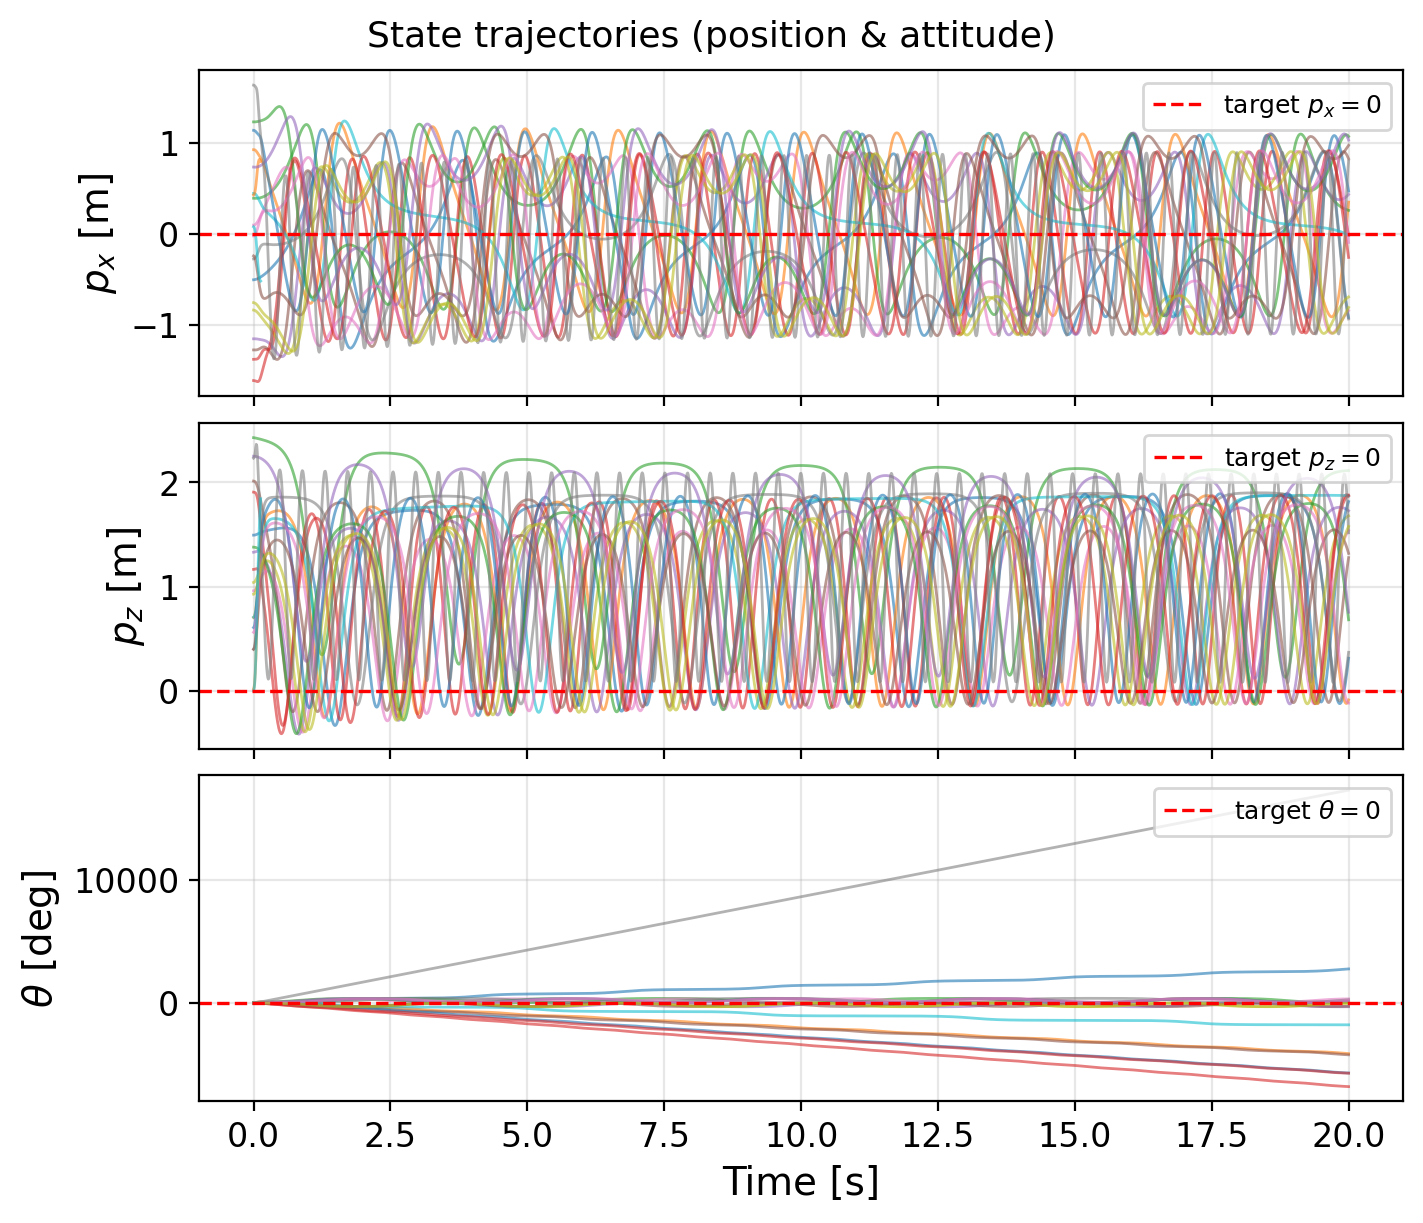

In [10]:
# State trajectories: positions and attitude angle
px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    3, 1, figsize=(700 * px_fig, 600 * px_fig), layout="constrained", sharex=True
)
fig.set_dpi(200)

for tx in traj_x:
    t = np.arange(tx.shape[0]) * dt
    axes[0].plot(t, tx[:, 0], lw=1.0, alpha=0.6)  # px
    axes[1].plot(t, tx[:, 1], lw=1.0, alpha=0.6)  # pz
    axes[2].plot(t, np.degrees(tx[:, 2]), lw=1.0, alpha=0.6)  # theta [deg]

# target: pz -> 0,  px -> 0,  theta -> 0
axes[0].axhline(0, color="red", lw=1.2, ls="--", label="target $p_x=0$")
axes[1].axhline(0, color="red", lw=1.2, ls="--", label="target $p_z=0$")
axes[2].axhline(0, color="red", lw=1.2, ls="--", label="target $\\theta=0$")

labels = ["$p_x$ [m]", "$p_z$ [m]", "$\\theta$ [deg]"]
for ax, lbl in zip(axes, labels):
    ax.set_ylabel(lbl, fontsize=14)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time [s]", fontsize=14)
fig.suptitle("State trajectories (position & attitude)", fontsize=13)
plt.show()